<a href="https://colab.research.google.com/github/tompickering-aur/Practice/blob/main/airbnb_LDN_TP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Airbnb hosts in London


# Question: Do newer Airbnb hosts perform worse in performance metrics (response rate and review score) than older hosts, in London?
# Hypotheses:
# H1: More than 50% of the current host base is made up of hosts that joined in the last 5 years
# H2: Hosts than joined in the last 5 years have a worse response rate when compared when the older hosts
# H3: Hosts than joined in the last 5 years have a worse review score when compared when the older hosts
# To Do:
# 1. Look at data to understand what we have
# 2. Clean data to make it easy to analysis
# 3. Group data
# 4. Plot: hosts by join date, response rate and review score by join date.
# Remaining: 5. Produce regression lines to determine relationships. 6. Do tests for other variables such as location, price and number of listings to see if their is colinearity
# Things tried: Tried to plot response time vs host joined date but data is in string format "less than an hour", "less than 4 hours" etc so did not work well with analysis
# AI used: Claude for plotting

In [7]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/listings.csv")

# checking what data looks like
print(df.head())
df.info()
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      id                         listing_url       scrape_id last_scraped  \
0  13913  https://www.airbnb.com/rooms/13913  20250914034649   2025-09-16   
1  15400  https://www.airbnb.com/rooms/15400  20250914034649   2025-09-16   
2  17402  https://www.airbnb.com/rooms/17402  20250914034649   2025-09-16   
3  24328  https://www.airbnb.com/rooms/24328  20250914034649   2025-09-18   
4  36274  https://www.airbnb.com/rooms/36274  20250914034649   2025-09-15   

            source                                               name  \
0      city scrape                Holiday London DB Room Let-on going   
1      city scrape                Bright Chelsea  Apartment. Chelsea!   
2      city scrape   Very Central Modern 3-Bed/2 Bath By Oxford St W1   
3  previous scrape                   Battersea live/work artist house   
4      city scrape  Bright 1 bedroom apt of

(96871, 79)

In [8]:
# data cleaning

# checking name of columns for cleaning
df.columns

# creating a new dataframe with the columns of interest and dropping unneeded columns
df = df[['id', 'host_id','host_since','host_response_rate','review_scores_rating']].copy()

# no need to rename columns, all follow convention

# checking what dates look like
print(df['host_since'].head())

# converting dates from string to datetime
df['host_since'] = pd.to_datetime(df['host_since']).copy()

print(df['host_response_rate'].dtype)
print(df['host_response_rate'].head())

# creating year variable
df['year'] = df['host_since'].dt.year

# check for missing values
df.isna().sum()

# drop missing values in host_since, host_response_rate, review_scores_rating
df = df.dropna(subset=['host_since', 'host_response_rate', 'review_scores_rating']).copy()

# dropping duplicates
df = df.drop_duplicates()

# converting %s into decimals, only if conversion has not already happened
if df['host_response_rate'].dtype == 'object':
    df['host_response_rate'] = df['host_response_rate'].str.replace('%', '').astype(float) / 100



0    2009-11-16
1    2009-12-05
2    2010-01-04
3    2009-09-28
4    2010-05-27
Name: host_since, dtype: object
object
0    100%
1     NaN
2     88%
3    100%
4    100%
Name: host_response_rate, dtype: object


In [9]:
# grouping
# grouping by year
hosts_per_year = df.groupby('year').size().reset_index(name='count')
meanyr_responserates = df.groupby('year')[['host_response_rate']].mean()
meanyr_reviewscores = df.groupby('year')[['review_scores_rating']].mean()

In [12]:
# answering hypotheses

# define cutoff year
cutoff_year = df['year'].max() - 5

# split into two groups
recent = df[df['year'] > cutoff_year]
established = df[df['year'] <= cutoff_year]

# print comparisons
print(f"--- Hosts ---")
print(f"Joined in last 5 years:  {len(recent):,}")
print(f"Joined before last 5 years: {len(established):,}")

print(f"\n--- Average Response Rate ---")
print(f"Joined in last 5 years:  {recent['host_response_rate'].mean():.1%}")
print(f"Joined before last 5 years: {established['host_response_rate'].mean():.1%}")

print(f"\n--- Average Review Score ---")
print(f"Joined in last 5 years:  {recent['review_scores_rating'].mean():.2f}")
print(f"Joined before last 5 years: {established['review_scores_rating'].mean():.2f}")

--- Hosts ---
Joined in last 5 years:  15,931
Joined before last 5 years: 36,465

--- Average Response Rate ---
Joined in last 5 years:  92.5%
Joined before last 5 years: 93.2%

--- Average Review Score ---
Joined in last 5 years:  4.55
Joined before last 5 years: 4.71


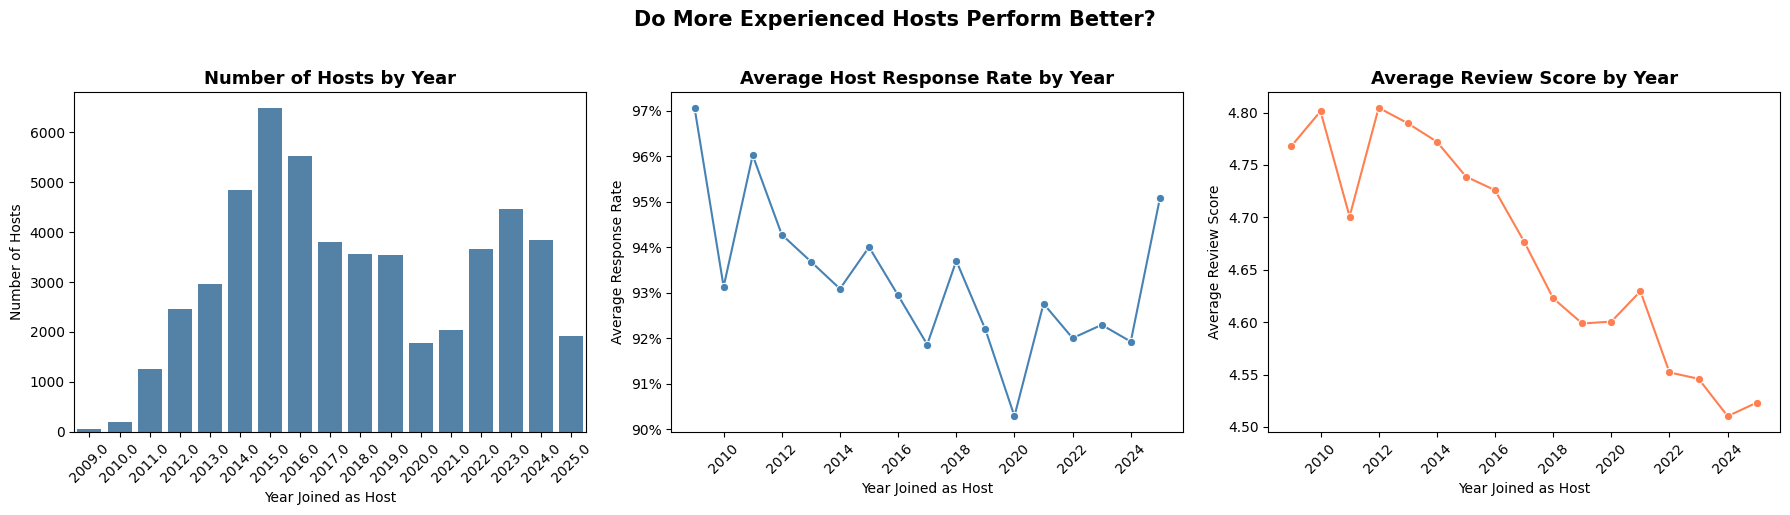

In [11]:
# plotting

import matplotlib.pyplot as plt
import seaborn as sns

# count hosts per year
hosts_per_year = df.groupby('year').size().reset_index(name='count')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Number of Hosts by Year
sns.barplot(data=hosts_per_year, x='year', y='count', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Hosts by Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year Joined as Host')
axes[0].set_ylabel('Number of Hosts')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Host Response Rate by Year
sns.lineplot(data=meanyr_responserates, x='year', y='host_response_rate', ax=axes[1], marker='o', color='steelblue')
axes[1].set_title('Average Host Response Rate by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year Joined as Host')
axes[1].set_ylabel('Average Response Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Review Scores Rating by Year
sns.lineplot(data=meanyr_reviewscores, x='year', y='review_scores_rating', ax=axes[2], marker='o', color='coral')
axes[2].set_title('Average Review Score by Year', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Year Joined as Host')
axes[2].set_ylabel('Average Review Score')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Do More Experienced Hosts Perform Better?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()